# Imports, File Paths, and Data Preprocessing

In [14]:
!pip install python-docx
import os
import warnings
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from docx import Document
from docx.shared import Inches, Pt, RGBColor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

## Setup Relative Paths (Pointing one level up to root directory)

In [4]:
BASE_DIR = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(BASE_DIR, "data", "train.csv")
REPORTS_DIR = os.path.join(BASE_DIR, "reports")
REPORT_DOCX = os.path.join(
    REPORTS_DIR, "Week_3_Unsupervised_Learning_Report.docx"
)


In [5]:
os.makedirs(REPORTS_DIR, exist_ok=True)


In [7]:
df = pd.read_csv(DATA_PATH)

In [8]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["Age"] = df.groupby("Pclass")["Age"].transform(
    lambda x: x.fillna(x.median())
)
df["Fare"] = df["Fare"].fillna(df["Fare"].median())


In [9]:
features = ["Pclass", "Age", "Fare", "FamilySize", "Sex"]
df_cluster = pd.get_dummies(df[features], columns=["Sex"], drop_first=True)
df_cluster["Fare"] = np.log1p(df_cluster["Fare"])


In [10]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cluster)

In [12]:
print("Data is ready")
df_cluster.head()

Data is ready


,Pclass,Age,Fare,FamilySize,Sex_male
0,3,22.0,2.110213,2,True
1,1,38.0,4.280593,2,False
2,3,26.0,2.188856,1,False
3,1,35.0,3.990834,2,False
4,3,35.0,2.202765,1,True


# Clustering, Generating Visualizations, and Saving Figures

In [15]:
inertia, sil_scores = [], []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_data)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(scaled_data, labels))

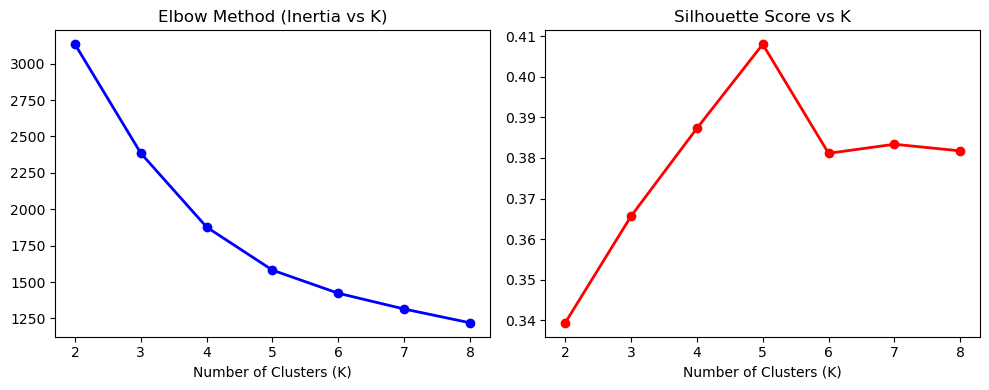

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(range(2, 9), inertia, "bo-", linewidth=2)
axes[0].set_title("Elbow Method (Inertia vs K)")
axes[0].set_xlabel("Number of Clusters (K)")
axes[1].plot(range(2, 9), sil_scores, "ro-", linewidth=2)
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xlabel("Number of Clusters (K)")
plt.tight_layout()
fig1_path = os.path.join(REPORTS_DIR, "01_elbow_silhouette.png")
plt.savefig(fig1_path, dpi=300)
plt.show()

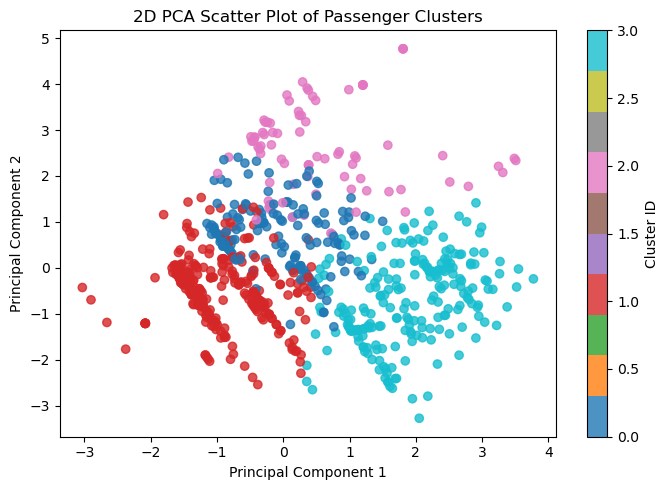

In [19]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(scaled_data)
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(scaled_data)
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    pca_coords[:, 0],
    pca_coords[:, 1],
    c=df["Cluster"],
    cmap="tab10",
    alpha=0.8,
)
plt.title("2D PCA Scatter Plot of Passenger Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster ID")
plt.tight_layout()
fig2_path = os.path.join(REPORTS_DIR, "02_pca_clusters.png")
plt.savefig(fig2_path, dpi=300)
plt.show()

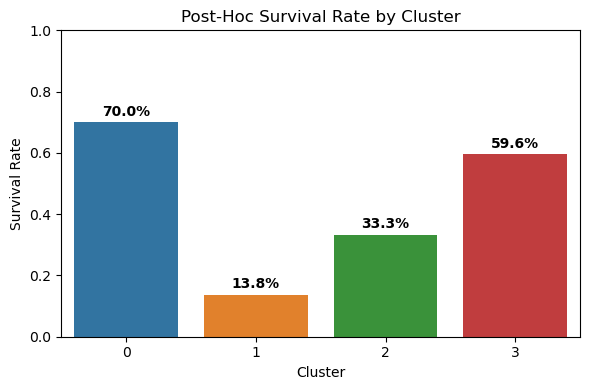

In [20]:
plt.figure(figsize=(6, 4))
sns.barplot(
    x="Cluster", y="Survived", data=df, errorbar=None, palette="tab10"
)
plt.title("Post-Hoc Survival Rate by Cluster")
plt.ylabel("Survival Rate")
plt.ylim(0, 1.0)
for i, rate in enumerate(df.groupby("Cluster")["Survived"].mean()):
    plt.text(
        i, rate + 0.02, f"{rate:.1%}", ha="center", fontweight="bold"
    )
plt.tight_layout()
fig3_path = os.path.join(REPORTS_DIR, "03_survival_clusters.png")
plt.savefig(fig3_path, dpi=300)
plt.show()